In [1]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch
import matplotlib.pyplot as plt
import numpy as np

# Path to the dataset
data_dir = "PlantVillage"

# Temporary convert to tensor
tmp_transform = transforms.Compose([
    transforms.ToTensor()
])

# Load tensor tmp dataset 
tmp_dataset = datasets.ImageFolder(root=data_dir, transform=tmp_transform)

# Use a DataLoader to iterate
tmp_loader = DataLoader(tmp_dataset, batch_size=64, shuffle=False, num_workers=2)

# Accumulators
mean = 0.0 # mean rgb of pixel in dataset 
std = 0.0 # std deviation
total_images = 0 # num of images so far (to calculate mean)

# iterate through dataloader
for images, _ in tmp_loader:
    batch_images = images.size(0)

    # Compute mean and std per batch (across H and W)
    mean += images.mean(dim=[0, 2, 3]) * batch_images # mean per channel (batch, height and width dimensions)
    std += images.std(dim=[0, 2, 3]) * batch_images   # not over channel 1, as that is the color channel, learned the hard way

    total_images += batch_images

# Final mean and std, divide accumulators by total images
mean /= total_images
std /= total_images 

print("Dataset Mean:", mean)
print("Dataset Std:", std)

Dataset Mean: tensor([0.4588, 0.4750, 0.4113])
Dataset Std: tensor([0.1887, 0.1657, 0.2025])


In [2]:
# Image size to fit to
IMG_SIZE = 224  

# Set up resizing and normalization 
# then add random transformations to lower overfitting
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(), # Flip horizontally at random
    transforms.RandomVerticalFlip(),   # Flip vertically at random
    transforms.RandomRotation(15),     # Random Rotate 15 degrees
    transforms.ColorJitter(            # Random small color variance
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist())
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist())
])


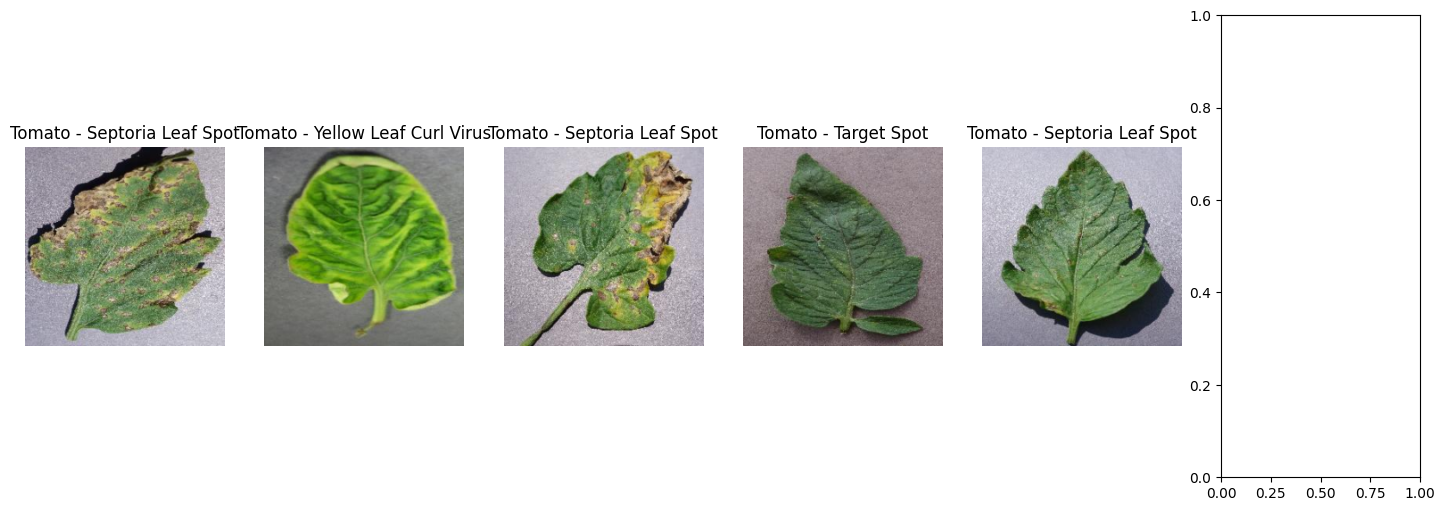

In [3]:
# Dataset for visualization (no normalization, only resize)
vis_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

vis_dataset = datasets.ImageFolder(root=data_dir, transform=vis_transforms)
vis_loader = torch.utils.data.DataLoader(vis_dataset, batch_size=6, shuffle=True)

# Get one batch
images, labels = next(iter(vis_loader))

# Plot images
fig, axs = plt.subplots(1, 6, figsize=(18, 6))
for i in range(5):
    img = images[i].permute(1, 2, 0).numpy()  # C,H,W -> H,W,C
    axs[i].imshow(img)
    axs[i].set_title(vis_dataset.classes[labels[i].item()])
    axs[i].axis('off')
plt.show()

In [4]:
# Load the full dataset 
full_dataset = datasets.ImageFolder(root=data_dir)

# Compute split sizes, 80% train, 20% test
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
# Split datasets using random_split
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

# Assign the transforms to each dataset
train_dataset.dataset.transform = train_transforms
test_dataset.dataset.transform = test_transforms

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

Train samples: 16510, Test samples: 4128


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4402392..2.504819].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.771487..2.6231217].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.558542..1.6094894].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.6768448..1.9133048].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.8188083..2.599461].


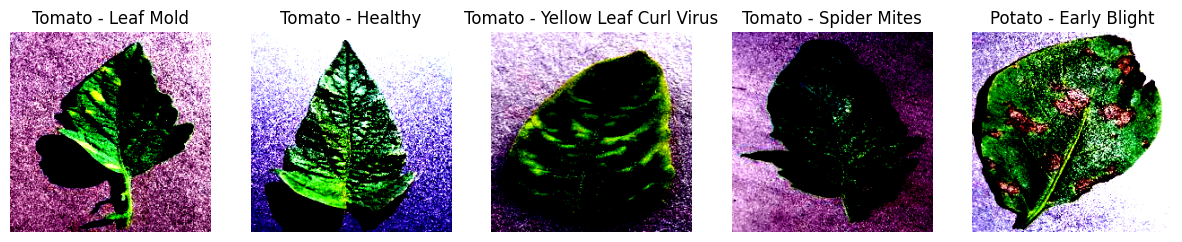

In [5]:
# Show a few normalized images
def show_normalized_batch(loader, class_names, num_images=5):
    images, labels = next(iter(loader))
    images = images[:num_images]
    labels = labels[:num_images]

    fig, axs = plt.subplots(1, num_images, figsize=(15, 5))
    for i, ax in enumerate(axs):
        img = images[i].permute(1, 2, 0).numpy()  # C,H,W -> H,W,C
        ax.imshow(img)  # shows normalized values (may look odd)
        ax.set_title(class_names[labels[i].item()])
        ax.axis('off')
    plt.show()

# Example usage
show_normalized_batch(train_loader, full_dataset.classes)

In [6]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class LeafCNN(nn.Module):
    def __init__(self, num_classes=15):
        super(LeafCNN, self).__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        
        # Max pooling
        self.pool = nn.MaxPool2d(2, 2)
        
        # Dropout
        self.dropout = nn.Dropout(0.4)
        
        # Fully connected layers
        self.fc1 = nn.Linear(128 * 28 * 28, 256)  # 224x224 -> 28x28 after 3 poolings
        self.fc2 = nn.Linear(256, num_classes)
    
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # [B, 32, 112, 112]
        x = self.pool(F.relu(self.conv2(x)))  # [B, 64, 56, 56]
        x = self.pool(F.relu(self.conv3(x)))  # [B, 128, 28, 28]
        x = x.view(-1, 128 * 28 * 28)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)  # output logits
        return x

    def train_model(self, train_loader, test_loader, epochs=10, lr=0.001, device="cuda"):
        self.to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(self.parameters(), lr=lr)

        train_losses, test_losses = [], []
        train_accuracies, test_accuracies = [], []

        for epoch in range(epochs):
            # Training
            self.train()
            running_loss, correct, total = 0.0, 0, 0
            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = self(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

            epoch_loss = running_loss / total
            epoch_acc = correct / total
            train_losses.append(epoch_loss)
            train_accuracies.append(epoch_acc)

            # Evaluation
            self.eval()
            running_loss, correct, total = 0.0, 0, 0
            with torch.no_grad():
                for images, labels in test_loader:
                    images, labels = images.to(device), labels.to(device)
                    outputs = self(images)
                    loss = criterion(outputs, labels)

                    running_loss += loss.item() * images.size(0)
                    _, predicted = torch.max(outputs, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            epoch_test_loss = running_loss / total
            epoch_test_acc = correct / total
            test_losses.append(epoch_test_loss)
            test_accuracies.append(epoch_test_acc)

            print(f"Epoch {epoch+1}/{epochs} -> "
                  f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f} | "
                  f"Test Loss: {epoch_test_loss:.4f}, Test Acc: {epoch_test_acc:.4f}")

        return train_losses, train_accuracies, test_losses, test_accuracies

In [7]:
# Instance the model
num_classes = len(full_dataset.classes)
model = LeafCNN(num_classes=num_classes)

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Using {device}:")

# Train the model
train_losses, train_acc, test_losses, test_acc = model.train_model(
    train_loader, test_loader, epochs=10, lr=0.001, device=device
)

Using cuda:
Epoch 1/10 -> Train Loss: 0.8018, Train Acc: 0.7446 | Test Loss: 0.3731, Test Acc: 0.8806
Epoch 2/10 -> Train Loss: 0.2874, Train Acc: 0.9061 | Test Loss: 0.2770, Test Acc: 0.9082
Epoch 3/10 -> Train Loss: 0.1867, Train Acc: 0.9377 | Test Loss: 0.2607, Test Acc: 0.9125
Epoch 4/10 -> Train Loss: 0.1227, Train Acc: 0.9596 | Test Loss: 0.2187, Test Acc: 0.9336
Epoch 5/10 -> Train Loss: 0.0996, Train Acc: 0.9657 | Test Loss: 0.3206, Test Acc: 0.9082
Epoch 6/10 -> Train Loss: 0.0739, Train Acc: 0.9758 | Test Loss: 0.2715, Test Acc: 0.9225
Epoch 7/10 -> Train Loss: 0.0662, Train Acc: 0.9789 | Test Loss: 0.3188, Test Acc: 0.9208
Epoch 8/10 -> Train Loss: 0.0652, Train Acc: 0.9798 | Test Loss: 0.3667, Test Acc: 0.9188
Epoch 9/10 -> Train Loss: 0.0794, Train Acc: 0.9768 | Test Loss: 0.2991, Test Acc: 0.9259
Epoch 10/10 -> Train Loss: 0.0677, Train Acc: 0.9794 | Test Loss: 0.2567, Test Acc: 0.9382


In [9]:
# Save
torch.save(model.state_dict(), "leaf_disease_model.pth")
print("Model saved.")

Model saved.


In [19]:
from sklearn.metrics import accuracy_score

# Load and evaluate saved model
model = LeafCNN(num_classes=15)  # or whatever your model class and number of classes is
model.load_state_dict(torch.load("leaf_disease_model.pth", weights_only=True))

model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

all_preds = []
all_labels = []

with torch.no_grad():  # no gradient needed for inference
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)  # get class with highest probability

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
eval_acc = accuracy_score(all_labels, all_preds)
print("Evaluation Accuracy: {:.2f}%".format(eval_acc * 100))

Evaluation Accuracy: 93.82%


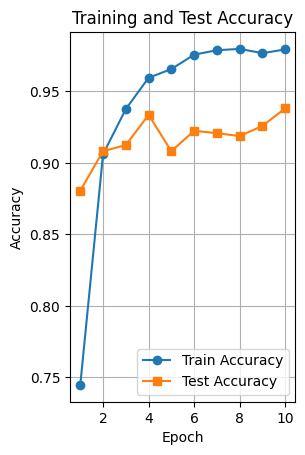

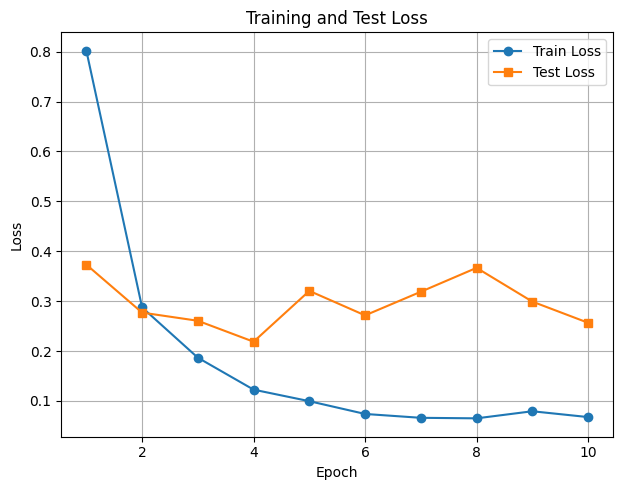

In [20]:
# Number of epochs inferred from the length of your lists
epochs = list(range(1, len(train_losses) + 1))

# Plot Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, train_acc, marker='o', label='Train Accuracy')
plt.plot(epochs, test_acc, marker='s', label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Test Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, marker='o', label='Train Loss')
plt.plot(epochs, test_losses, marker='s', label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

<Figure size 1200x1200 with 0 Axes>

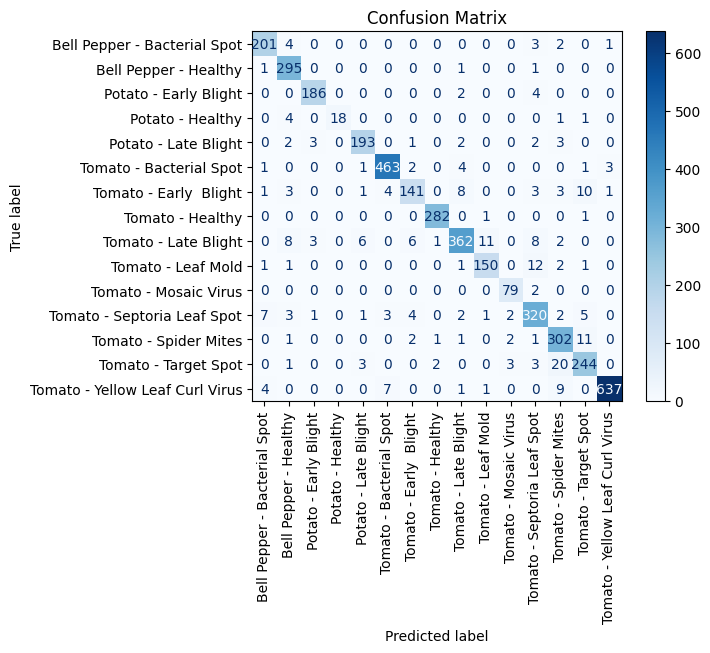

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Make sure the model is in evaluation mode
model.eval()

class_names = full_dataset.classes  # original dataset classes

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# Plot the confusion matrix
plt.figure(figsize=(12,12))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=90)
plt.title("Confusion Matrix")
plt.show()

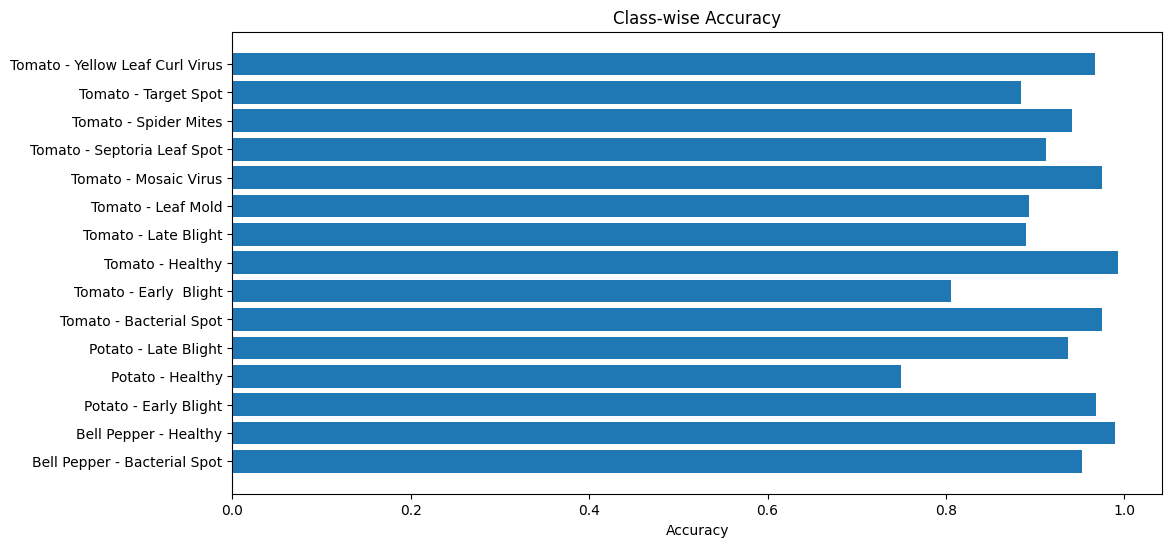

In [28]:
class_correct = np.zeros(len(full_dataset.classes))
class_total = np.zeros(len(full_dataset.classes))

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        for i in range(len(labels)):
            label = labels[i]
            class_correct[label] += (preds[i] == label).item()
            class_total[label] += 1

class_acc = class_correct / class_total

plt.figure(figsize=(12,6))
plt.barh(full_dataset.classes, class_acc)
plt.xlabel("Accuracy")
plt.title("Class-wise Accuracy")
plt.show()